<a href="https://colab.research.google.com/github/csorty/car/blob/main/dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Генерация тестовых данных...
Запуск DBSCAN с eps=1.5, min_pts=4...

=== Результаты кластеризации ===
Всего точек: 65
Найдено кластеров: 3
  Кластер 0: 17 точек
  Кластер 1: 30 точек
  Кластер 2: 16 точек
  Шум: 2 точек


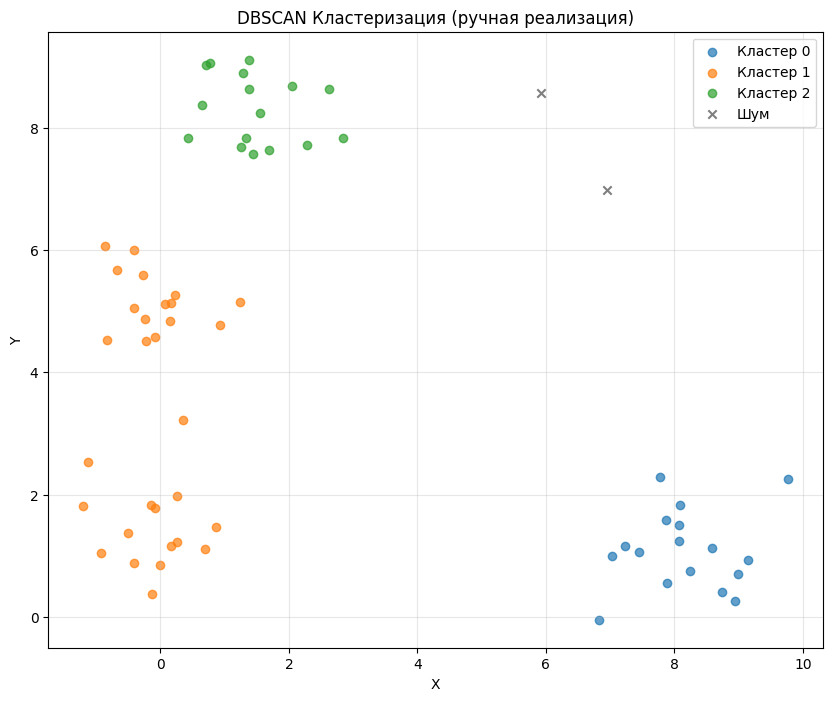

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.cluster = -1  # -1 означает некластеризован
        self.visited = False
        self.is_noise = False

def euclidean_distance(p1, p2):
    """Вычисляет евклидово расстояние между двумя точками"""
    return np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)

def find_neighbors(point, points, eps):
    """Находит всех соседей точки в радиусе eps"""
    neighbors = []
    for i, p in enumerate(points):
        if euclidean_distance(point, p) <= eps:
            neighbors.append(i)
    return neighbors

def dbscan_manual(points, eps, min_pts):
    """
    Реализация DBSCAN алгоритма

    points: список объектов Point
    eps: радиус окрестности
    min_pts: минимальное количество точек для образования кластера
    """
    cluster_id = 0

    for i, point in enumerate(points):
        # Пропускаем уже посещенные точки
        if point.visited:
            continue

        point.visited = True

        # Находим соседей
        neighbors = find_neighbors(point, points, eps)

        # Если недостаточно соседей, помечаем как шум
        if len(neighbors) < min_pts:
            point.is_noise = True
        else:
            # Создаем новый кластер
            expand_cluster(points, point, neighbors, cluster_id, eps, min_pts)
            cluster_id += 1

    return cluster_id

def expand_cluster(points, point, neighbors, cluster_id, eps, min_pts):
    """Расширяет кластер, добавляя все достижимые точки"""
    point.cluster = cluster_id

    # Используем очередь для BFS
    queue = deque(neighbors)

    while queue:
        current_idx = queue.popleft()
        current_point = points[current_idx]

        if not current_point.visited:
            current_point.visited = True

            # Находим соседей текущей точки
            current_neighbors = find_neighbors(current_point, points, eps)

            # Если достаточно соседей, добавляем их в очередь
            if len(current_neighbors) >= min_pts:
                for neighbor_idx in current_neighbors:
                    if neighbor_idx not in queue and points[neighbor_idx].cluster == -1:
                        queue.append(neighbor_idx)

        # Добавляем точку в кластер, если она еще не в кластере
        if current_point.cluster == -1:
            current_point.cluster = cluster_id

def generate_points(centers_count=3, points_count=10, spread=0.3):
    """Генерирует тестовые данные"""
    points = []

    # Генерируем кластеризованные точки
    for _ in range(centers_count):
        center_x = random.uniform(0, 10)
        center_y = random.uniform(0, 10)
        for _ in range(points_count):
            x = random.gauss(center_x, spread)
            y = random.gauss(center_y, spread)
            points.append(Point(x, y))

    # Добавляем немного шума
    for _ in range(5):
        x = random.uniform(0, 10)
        y = random.uniform(0, 10)
        points.append(Point(x, y))

    return points

def plot_clusters(points):
    """Визуализирует результаты кластеризации"""
    # Группируем точки по кластерам
    clusters = {}
    noise_points = []

    for p in points:
        if p.cluster == -1 or p.is_noise:
            noise_points.append((p.x, p.y))
        else:
            if p.cluster not in clusters:
                clusters[p.cluster] = []
            clusters[p.cluster].append((p.x, p.y))

    # Рисуем кластеры разными цветами
    plt.figure(figsize=(10, 8))

    for cluster_id, points_list in clusters.items():
        x_vals = [p[0] for p in points_list]
        y_vals = [p[1] for p in points_list]
        plt.scatter(x_vals, y_vals, label=f'Кластер {cluster_id}', alpha=0.7)

    # Рисуем шум черным цветом
    if noise_points:
        x_noise = [p[0] for p in noise_points]
        y_noise = [p[1] for p in noise_points]
        plt.scatter(x_noise, y_noise, c='black', marker='x', label='Шум', alpha=0.5)

    plt.title('DBSCAN Кластеризация (ручная реализация)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def print_cluster_info(points):
    """Выводит информацию о кластерах"""
    cluster_counts = {}
    noise_count = 0

    for p in points:
        if p.cluster == -1 or p.is_noise:
            noise_count += 1
        else:
            if p.cluster not in cluster_counts:
                cluster_counts[p.cluster] = 0
            cluster_counts[p.cluster] += 1

    print("\n=== Результаты кластеризации ===")
    print(f"Всего точек: {len(points)}")
    print(f"Найдено кластеров: {len(cluster_counts)}")
    for cluster_id, count in sorted(cluster_counts.items()):
        print(f"  Кластер {cluster_id}: {count} точек")
    print(f"  Шум: {noise_count} точек")

def main():
    # Генерируем тестовые данные
    print("Генерация тестовых данных...")
    points = generate_points(centers_count=4, points_count=15, spread=0.5)

    # Параметры DBSCAN
    eps = 1.5  # Радиус окрестности
    min_pts = 4  # Минимальное количество точек для кластера

    # Запускаем кластеризацию
    print(f"Запуск DBSCAN с eps={eps}, min_pts={min_pts}...")
    num_clusters = dbscan_manual(points, eps, min_pts)

    # Выводим информацию
    print_cluster_info(points)

    # Визуализируем результат
    plot_clusters(points)



if __name__ == "__main__":
    main()